# Time Limit transactions untangling 



Here we demonstarte a sample pipeline, for aplication of heuristics for time limit transactions untangling. 

File **Transactions.jsonl** contains a transactions sample for the experiment

File **Solver.out** contains shared send solver from https://github.com/Englekh/shared-send-classification

In [1]:
import matplotlib.pyplot as plt
import subprocess
import itertools
import numpy as np
import os
import json
import time

# Heuristic 1 : Preemptive grouping

Here we applying the first heuristic for to the transactions

In [2]:
# This function calculates heuristic for a given transaction

def Apply_Heu1(Ins, Outs):
    Ins.sort()
    Ins.reverse()
    Outs.sort()
    Outs.reverse()

    # Filtering non shared-send transactions
    if (len(Ins) < 2 or len(Outs) < 2):
        return Ins, Outs, False

    # Checking heuristic for inputs
    val = np.sum(Ins[1:])
    if (Ins[0] > val):
        flag = False
        sz = len(Outs)
        for i in range(sz):
            if (Ins[0] > Outs[sz - i - 1] > val):
                Ins[0] -= Outs[sz - i - 1]
                Outs.pop(sz - i - 1)
                flag = True
        if (flag):
            return Ins, Outs, True


    # Checking heuristic for outputs
    val = np.sum(Outs[1:])
    if (Outs[0] > val):

        flag = False
        sz = len(Ins)
        for i in range(sz):
            if (Outs[0] > Ins[sz - i - 1] > val):
                Outs[0] -= Ins[sz - i - 1]
                Ins.pop(sz - i - 1)
                flag = True
        if (flag):
            return Ins, Outs, True

    return Ins, Outs, False

In [3]:
# Here we calculate heuristic for give transactions

file = "Transactions.jsonl"
outfile = "Transactions_grouped.txt"
outfile2 = "Transactions_grouped.jsonl"

# Reading transactions file
Transactions = []
f_in = open(file, 'r')
for line in f_in:
    Transactions.append(json.loads(line))
f_in.close()

# Preparing file for the solмer
f_out = open(outfile, 'w')
f_out.write("tsk\n")
f_out.write(f"{len(Transactions)}\n")
f_out2 = open(outfile2, 'w')

for i in range(len(Transactions)):
    print(f"\r Current transaction {i} out of {len(Transactions)}", end = '')
    f_out.write(f">{i}\n")

    # Reading transaction
    Ins = list(Transactions[i][0].values())
    Outs = list(Transactions[i][1].values())

    # Applying heuristic
    Ins, Outs, res = Apply_Heu1(Ins, Outs)
    while (res):
        Ins, Outs, res = Apply_Heu1(Ins, Outs)

    # Writing result
    total_counter = 0
    f_out.write(f"Inputs:{len(Ins)}\n")
    for el in Ins:
        f_out.write(f"Group{total_counter}:{el}\n" )
        total_counter += 1
    f_out.write(f"Outputs:{len(Outs)}\n")
    for el in Outs:
        f_out.write(f"Group{total_counter}:{el}\n" )
        total_counter += 1

    tr = [{}, {}, 0]
    fee = 0
    for el in Ins:
        tr[0][f"aaaaaaaaaa{total_counter}"] = el
        fee += el
        total_counter += 1
    for el in Outs:
        tr[1][f"aaaaaaaaaa{total_counter}"] = el
        fee -= el
        total_counter += 1
    tr[2] = fee
    f_out2.write(json.dumps(tr))
    f_out2.write('\n')

f_out.close()
f_out2.close()

 Current transaction 999 out of 1000

In [4]:
#Applying solver
Time_limit = 10
proc = subprocess.Popen(["./Solver.out", "Transactions_grouped.txt", "Transactions_solved.txt", f'{Time_limit}'])
proc.wait()

0

In [5]:
# Reading resulted transactions 
file = "Transactions_grouped.jsonl"

Transactions = []

f_in = open(file, 'r')
for line in f_in:
    Transactions.append(json.loads(line))
Transactions = np.array(Transactions)
f_in.close()

In [6]:
# Collect result of calculation 

def Check_Heu1(Transactions, res):
    Result = []
    for i in range(len(Transactions)):
        print(f"\r{i + 1}/{len(Transactions)}", end = '')

        if (res[i] == "# VERDICT AMBIGUOUS\n"):
            Result.append(("Ambigeus", "Heu1"))
        elif (res[i] == "# TIME LIMIT EXTENDED\n"):
            Result.append(("None", "Heu1"))
        elif (res[i] == '# VERDICT SEPARABLE\n'):
            Result.append(("Separable", "Heu1"))
        else:
            flag = False
            for el in Transactions[i][0].values():
                if el < Transactions[i][2]:
                    flag = True
            # Result for simple result is not simple due to grouping
            if flag:
                Result.append(("Separable", "Heu1"))
            else:
                Result.append(("Simple", "Heu1"))
                        
    return Result

1000/1000

(array([222.,   0.,   0., 151.,   0.,   0., 532.,   0.,   0.,  95.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

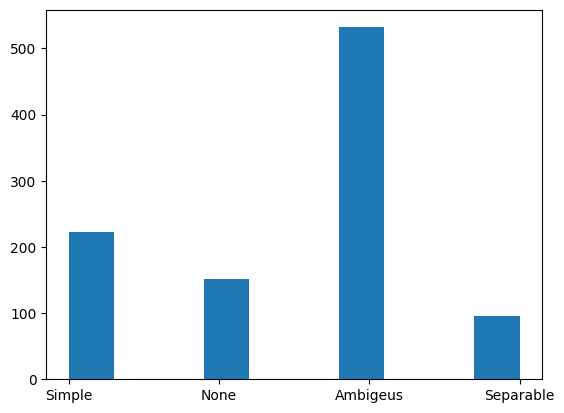

In [7]:
res_heu1 = []
f_in = open('Transactions_solved.txt', 'r')
for line in f_in:
    if ("#" in line):
        res_heu1.append(line)
f_in.close()
res_heu1 = np.array(res_heu1)
Result = Check_Heu1(Transactions, res_heu1)

DrawVal = []
for el in Result:
    DrawVal.append(el[0])
plt.hist(DrawVal)

------------------------------------------------------------

# Calculating types

## Heuristic 2: Connectable singleton

In [8]:
# Function checks if pair of subsets is connectable
def Check_Sets(Input_size, Output_size, Margin):
    if (Input_size < Output_size):
        return -1
    if (Input_size > Output_size + Margin):
        return 1
    return 0

In [9]:
# Smart subset iterator
class SmartSubArray:

    def __init__(self, Array):
        self.Array = Array
        self.Flags = []
        self.Total = 0
        for _ in Array:
            self.Flags.append(False)
        

    def next_small(self):
        CurrentPos = 0
        while (CurrentPos < len(self.Flags) and self.Flags[CurrentPos]):
            self.Total -= self.Array[CurrentPos]
            self.Flags[CurrentPos] = False
            CurrentPos += 1

        if (CurrentPos < len(self.Flags)):
            self.Total += self.Array[CurrentPos]
            self.Flags[CurrentPos] = True
            return self.Total
        return None

    
    def next_big(self):
        CurrentPos = 0
        while (CurrentPos < len(self.Flags) and (not self.Flags[CurrentPos])):
            CurrentPos += 1

        if (CurrentPos >= len(self.Flags)):
            raise Exception('Exceeded array length')
            
        while (CurrentPos < len(self.Flags) and self.Flags[CurrentPos]):
            self.Total -= self.Array[CurrentPos]
            self.Flags[CurrentPos] = False
            CurrentPos += 1
            
        if (CurrentPos < len(self.Flags)):
            self.Total += self.Array[CurrentPos]
            self.Flags[CurrentPos] = True
            return self.Total
        return None

In [10]:
# Iterates through input array
def check_value_inputs(Values, Minimal, Diff, limit = 10):
    cur_t = time.time()
    Ar = SmartSubArray(Values)

    val = Ar.next_small()
    counter = 0
    
    while (val):
        if (time.time() - cur_t > limit):
            return "Nan"
        res = Check_Sets(val, Minimal, Diff)
        if (res == -1):
            val = Ar.next_small()
        elif (res == 1):
            val = Ar.next_big()
        else:
            counter += 1
            if (counter == 2):
                return "Ambigeus"
            val = Ar.next_small()

    if (counter == 0):
        return "Simple"
    else:
        return "Separable"

# Iterates through outputs array
def check_value_outputs(Values, Minimal, Diff, limit = 10):
    cur_t = time.time()
    Ar = SmartSubArray(Values)

    val = Ar.next_small()
    counter = 0
    
    while (val):
        if (time.time() - cur_t > limit):
            return "Nan"
        res = Check_Sets(Minimal, val, Diff)
        if (res == -1):
            val = Ar.next_small()
        elif (res == 1):
            val = Ar.next_big()
        else:
            counter += 1
            if (counter == 2):
                return "Ambigeus"
            val = Ar.next_small()

    if (counter == 0):
        return "Simple"
    else:
        return "Separable"

In [11]:
def Check_Heu2(Transactions, Results):
    for i in range(len(Transactions)):
        print(f"\r{i + 1}/{len(Transactions)}", end = '')
        
        if (Results[i][0] == "None"):
            if (len(Transactions[i][0]) == 2):
                Ins = list(Transactions[i][0].values())
                Ins.sort()
                Outs = list(Transactions[i][1].values())
                Outs.sort()
                Results[i] = (check_value_outputs(Outs, Ins[0], Transactions[i][2]), "Heu2")
            elif (len(Transactions[i][1]) == 2):
                Ins = list(Transactions[i][0].values())
                Ins.sort()
                Outs = list(Transactions[i][1].values())
                Outs.sort()
                Results[i] = (check_value_inputs(Ins, Outs[0], Transactions[i][2]), "Heu2")
            else:
                Results[i] = ("Nan", "Heu2")

Check_Heu2(Transactions, Result)

1000/1000

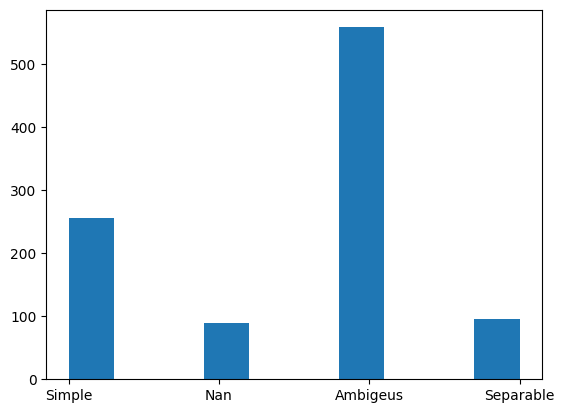

(array([849.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 151.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

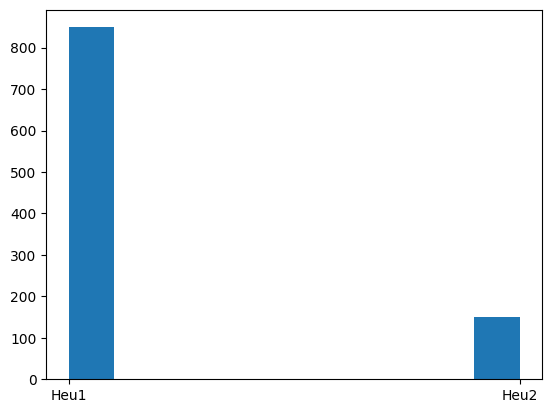

In [12]:
DrawVal = []
DrawHeu = []
for el in Result:
    DrawVal.append(el[0])
    DrawHeu.append(el[1])
plt.hist(DrawVal)
plt.show()
plt.hist(DrawHeu)

## Heuristic 3

Can use heuristic 1

In [13]:
def Apply_Heu3_Tr(Trans):
    Ins = list(Trans[0].values())
    Ins.sort()
    Outs = list(Trans[1].values())
    Outs.sort()
    val = -1
    
    for i in range(1, len(Ins)):
        if (Ins[i - 1] == Ins[i]) and (Ins[i - 1] != val):
            res = check_value_inputs(Outs, Ins[i-1], Trans[2])
            if (res == "Ambigeus" or res == "Separable"):
                return "Ambigeus"
            val = Ins[i]

    val = -1
    for j in range(1, len(Outs)):
        if (Outs[j - 1] == Outs[j] and  Outs[j] != val):
            res = check_value_outputs(Ins, Outs[j-1], Trans[2])
            if (res == "Ambigeus" or res == "Separable"):
                return res
            val = Outs[j - 1]
    return "Nan"

In [14]:
def Check_Heu3(Transactions, Results):
    for i in range(len(Transactions)):
        print(f"\r{i + 1}/{len(Transactions)}", end = '')
        if (Results[i][0] == "Nan"):
            Results[i] = (Apply_Heu3_Tr(Transactions[i]), "Heu3")

Check_Heu3(Transactions, Result)

1000/1000

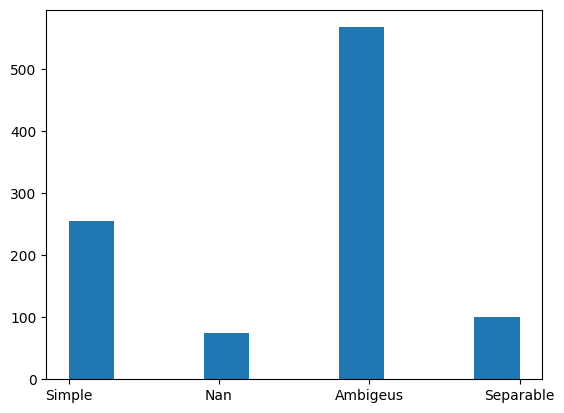

(array([849.,   0.,   0.,   0.,   0.,  90.,   0.,   0.,   0.,  61.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

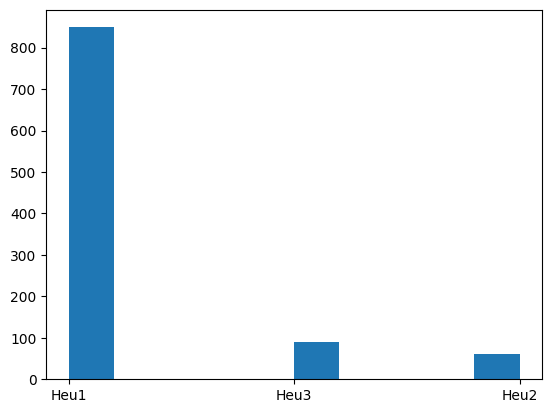

In [15]:
DrawVal = []
DrawHeu = []
for el in Result:
    DrawVal.append(el[0])
    DrawHeu.append(el[1])
plt.hist(DrawVal)
plt.show()
plt.hist(DrawHeu)

# Apply solver
Here we use 10 as a rational maximum for the subsets to iterate over. 

In [16]:
from ortoolpy import knapsack
import signal

def signal_handler(signum, frame):
    raise Exception("Timed out!")

def check_solver(timer, objects, total):
    signal.signal(signal.SIGALRM, signal_handler)
    signal.alarm(timer) 
    try:
        return knapsack(objects, objects, total)
    except:
        return (-1, [])

In [17]:
def TrySolveFull(Transaction, i, total):
    Ins = list(Transaction[0].values())
    Ins.sort()
    Outs = list(Transaction[1].values())
    Outs.sort()

    Fee = Transaction[2]

    if (len(Ins) <= 10):
        res = []
        counter = 0
        Totals  = []
        for count in range(len(Ins)):
            print(f"\r{count}/{len(Ins)}, total {i} / {total}", end = '') 
            res = check_solver(60, Outs, Ins[count])
            if (res[0] > Ins[count] - Fee and res[0] > 0):
                res2 = check_solver(60, Outs, res[0] - 1)
                if (res2 is not None and res2[0] > Ins[count] - Fee):
                    return "Ambigeus"

                for j in range(len(res[1])):
                    if (res[1][j] > 0 and (Outs[res[1][j]] == Outs[res[1][j] - 1]) and not ((res[1][j] - 1) in res[1])):
                        return "Ambigeus"

                    if (res[1][j] + 1 < len(Outs) and (Outs[res[1][j]] == Outs[res[1][j] + 1]) and not ((res[1][j] + 1) in res[1])):
                        return "Ambigeus"

                Totals.append(res)

        for j in range(len(Totals)):
            for k in range(j + 1, len(Totals)):
                #print(Totals[k], Totals[j])
                if len(np.intersect1d(Totals[j][1], Totals[k][1])) > 0:
                    return "Ambigeus"
        
        return "Nan"


    
    if (len(Outs) <= 10):
        res = []
        counter = 0
        Totals  = []
        for count in range(len(Outs)):
            print(f"\r{count}/{len(Outs)}, total {i} / {total}", end = '') 
            res = check_solver(60, Ins, Outs[count] + Fee)
            if (res[0] > Outs[count] and res[0] > 0):
                res2 = check_solver(60, Ins, res[0] - 1)
                if (res2 is not None and res2[0] > Outs[count]):
                    return "Ambigeus"

                for j in range(len(res[1])):
                    if (res[1][j] > 0 and (Ins[res[1][j]] == Ins[res[1][j] - 1]) and not ((res[1][j] - 1) in res[1])):
                        return "Ambigeus"

                    if (res[1][j] + 1 < len(Ins) and (Ins[res[1][j]] == Ins[res[1][j] + 1]) and not ((res[1][j] + 1) in res[1])):
                        return "Ambigeus"

                Totals.append(res)

        for j in range(len(Totals)):
            for k in range(j + 1, len(Totals)):
                #print(Totals[k], Totals[j])
                if len(np.intersect1d(Totals[j][1], Totals[k][1])) > 0:
                    return "Ambigeus"
        
        return "Nan"

    return "Nan"

In [18]:
for i in range(len(Transactions)):
    if (Result[i][0] == "Nan"):
        Result[i] = (TrySolveFull(Transactions[i], i, len(Transactions)), "Solv1")

0/2, total 958 / 1000

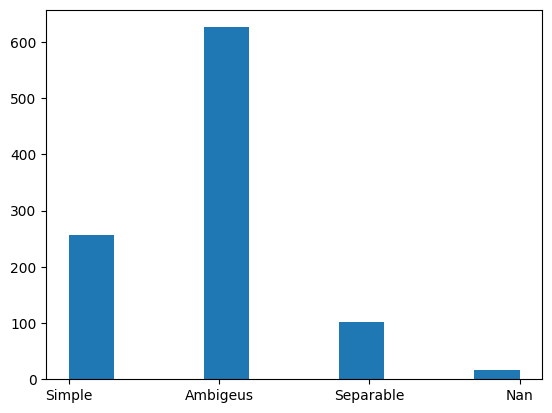

(array([849.,   0.,   0.,  75.,   0.,   0.,  61.,   0.,   0.,  15.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

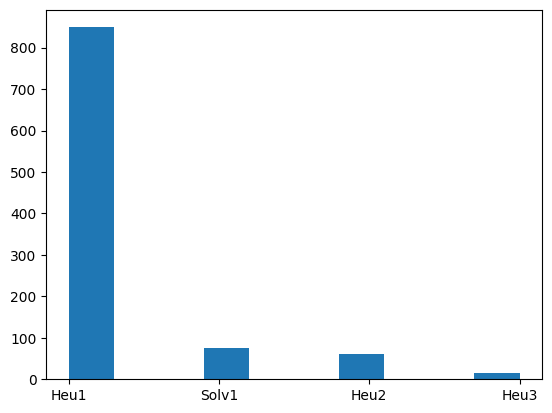

In [19]:
DrawVal = []
DrawHeu = []
for el in Result:
    DrawVal.append(el[0])
    DrawHeu.append(el[1])
plt.hist(DrawVal)
plt.show()
plt.hist(DrawHeu)

In [20]:
#Looking for simple transactions
def TrySolveFull2(Trans, i, total):
    Ins = list(Trans[0].values())
    Ins.sort()
    Outs = list(Trans[1].values())
    Outs.sort()

    Fee = Trans[2]

    if (len(Ins) <= 10):
        res = []
        counter = 0
        Totals  = []
        for count in range(1, len(Ins)):
            print(f"\r{count}/{len(Ins)}, total {i} / {total}", end = '') 
            for sub in itertools.combinations(Ins, count):
                subsum = np.sum(sub)
                res = check_solver(60, Ins, Outs[count] + Fee)
                if (not res):
                    return "Nan"
                if (res[0] > Ins[count] - Fee and res[0] > 0):
                    return "Nan"
                if (res[0] < 0):
                    return "Nan"
        return "Simple"

    
    if (len(Outs) <= 10):
        res = []
        counter = 0
        Totals  = []
        for count in range(1, len(Outs)):
            print(f"\r{count}/{len(Outs)}, total {i} / {total}", end = '') 
            for sub in itertools.combinations(Outs, count):
                subsum = np.sum(sub)
                res = check_solver(60, Ins, Outs[count] + Fee)
                if (not res):
                    return "Nan"
                if (res[0] > Ins[count] - Fee and res[0] > 0):
                    return "Nan"
                if (res[0] < 0):
                    return "Nan"
        
        return "Simple"

    return "Nan"

In [ ]:
for i in range(len(Transactions)):
    if (Result[i][0] == "Nan"):
        Result[i] = (TrySolveFull2(Transactions[i], i, len(Transactions)), "Solv1")

1/3, total 386 / 1000

In [ ]:
DrawVal = []
DrawHeu = []
for el in Result:
    DrawVal.append(el[0])
    DrawHeu.append(el[1])
plt.hist(DrawVal)
plt.show()
plt.hist(DrawHeu)